In [3]:
%load_ext autoreload
%autoreload 2

In [5]:
import src.paths
import numpy as np
from datetime import datetime
import pathlib


def get_exp_description(exp_name):
    with open(src.paths.raw_data_path / exp_name / f"EX{exp_name.split('_')[0]}.log", "r") as f:
        lines = f.readlines()
        for line in lines:
            if "exp_description" in line:
                return line
    return None

def process_images(img_files, dcirc):
    # function to process the images and return the grayscales
    res = []
    for img_file in img_files:
        img_path = str(img_file)
        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_blur = cv2.medianBlur(gray, 9)
        dcirc = src.circles.get_circles(img_blur, sort=True, plot=False)
        res.append(src.circles.get_grayscales(img_blur, dcirc))

    return np.array(res)


def calculate_freezing_idxs(grayscales_evolution):
    # function to calculate the freezing indices
    freezing_idxs = []
    for i in range(grayscales_evolution.shape[-1]):
        grayscales_diffs = [s - t for s, t in zip(grayscales_evolution[:, i], grayscales_evolution[1:, i])]
        freezing_idxs.append(np.argmax(grayscales_diffs) + 1)
    return freezing_idxs

def calculate_freezing_times(img_files, freezing_idxs):
    # function to calculate the freezing times
    freezing_times = []
    for i, idx in enumerate(freezing_idxs):
        freezing_times.append(datetime.strptime(img_files[freezing_idxs[i]].stem, "%Y%m%d%H%M%S"))
    return np.array(freezing_times)

def process_sensors_data(exp_name, freezing_idxs, freezing_times):
    # function to process the sensors data and return the t and ff arrays
    str2date = lambda x: datetime.strptime(x.decode("utf-8"), '%Y-%m-%d %H:%M:%S')
    data = np.genfromtxt(src.paths.raw_data_path / exp_name / 'sensors_data.csv', 
                     delimiter=',', 
                     dtype=None,
                     names=True, 
                     converters = {0: str2date})
    
    t = []
    ff = []
    p = pathlib.Path(src.paths.processed_data_path / exp_name)
    p.mkdir(parents=True, exist_ok=True)

    with open(src.paths.processed_data_path / exp_name / 'frozen_fraction_report.csv', 'w') as fo:
        fo.write(f'index, temp, ff\n')
        for i, line in enumerate(data):
            t.append(line[2])
            ff.append((freezing_times <= line['datetime']).sum()/freezing_idxs.__len__())
            fo.write(f'{i},{t[-1]},{ff[-1]}\n')

def process_experiment(exp_name):
    print(get_exp_description(exp_name))
    
    img_dir = src.paths.raw_data_path / exp_name / 'pics'

    # get a list of all PNG files in the directory
    img_files = [f for f in img_dir.iterdir() if f.is_file() and f.suffix == ".png"]

    # sort the list of images
    img_files.sort()
    
    # Read first image and use that circles positions for all the analysis
    img = cv2.imread(str(img_files[0]))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.medianBlur(gray, 7)
    dcirc = src.circles.get_circles(img_blur, sort=True, plot=False)
    
    grayscales_evolution = process_images(img_files, dcirc)
    
    freezing_idxs = calculate_freezing_idxs(grayscales_evolution)
    
    freezing_times = calculate_freezing_times(img_files, freezing_idxs)
    
    process_sensors_data(exp_name, freezing_idxs, freezing_times)

In [6]:
experiments =  [
    "202302160954_TF4",
    "202302161030_TF5",
    "202302161112_MQ6",
    "202302161151_MQ8",
    "202302161223_MQ7",
#     "202302161256_MQ9",
    "202302161406_MQ10",
#     "202302161439_MQ11",
    "202302161517_HEL20211123",
#     "202302161542_MQ12"
    ]

In [7]:
import cv2
from src import circles

for exp_name in experiments:
    process_experiment(exp_name)

    "exp_description": "TF4 - From MeOH glass. Vinyl gloves. Syringe rinsed with Mili-Q (new for the day the syringe). Hood with no ventilation, same as yesterday.",

    "exp_description": "TF5 - From MeOH glass. Vinyl gloves. Syringe rinsed with Mili-Q (new for the day the syringe). Hood with no ventilation, same as yesterday.

    "exp_description": "MQ6 - Mili-Q water from yesterday's glass covered with Parafilm. Same syringe for all the day. 50 uL droplets\n",

    "exp_description": "MQ8 - Mili-Q water from yesterday's glass covered with Parafilm. Same syringe for all the day. 25 uL droplets\n",

    "exp_description": "MQ7 - Mili-Q water from yesterday's glass covered with Parafilm. Same syringe for all the day. 100 uL droplets\n",

    "exp_description": "MQ10 - New pipette (same as MQ9). Clean the out part with ethanol and rinse with Mili-Q (fill & discard). No sticker, just plexiglas.",

    "exp_description": "HEL20211123 - Filter placed in plastic tube with 10 mL of Mili-Q 

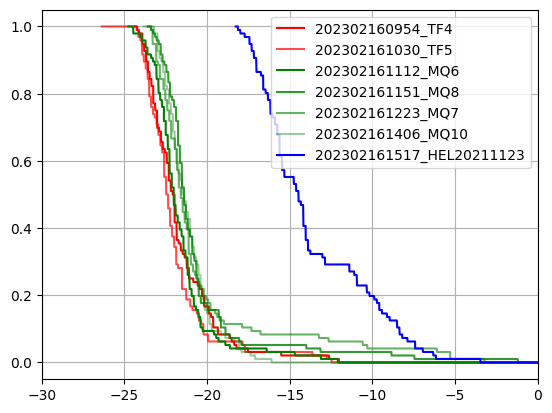

In [8]:
import matplotlib.pyplot as plt

a1 = 1
a2 = 1
a3 = 1

plt.figure()

for exp_name in experiments:
    
    data = np.genfromtxt(src.paths.processed_data_path / exp_name / 'frozen_fraction_report.csv', 
                     delimiter=',', 
                     dtype=None,
                     names=True)
    if "MQ" in get_exp_description(exp_name):
        plt.plot(data['temp'], data['ff'], label=exp_name, color='g', alpha=a1)
        a1 -= 0.2
    elif "TF" in get_exp_description(exp_name):
        plt.plot(data['temp'], data['ff'], label=exp_name, color='r', alpha=a2)
        a2 -= 0.3
    else:
        plt.plot(data['temp'], data['ff'], label=exp_name, color='b')

plt.legend()
plt.xlim(-30, 0)
plt.grid()